## 文本資料進行sklearn分類

# 標籤數量資料均衡化 (Class Balancing) 處理

In [78]:
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 參數設定
INPUT_CSV = "run_results/ltn1.csv"  # 原始資料
MIN_COUNT_MERGE = 1000             # 少於此數量的類別合併到 "其他"
MAX_COUNT_PER_CLASS = 7000         # 多於此數量的類別下取樣上限

# 1. 讀取 CSV
df = pd.read_csv(INPUT_CSV)

if "class" not in df.columns:
    raise ValueError("CSV 中沒有 'class' 欄位")

# 扣除空白
df = df.dropna(subset=["class"])
# 扣除重複的 rows
df = df.drop_duplicates()

# 2. 計算各類別數量
label_counts = df["class"].value_counts()
print("原始類別數量：")
print(label_counts)
print(f"總數量: {len(df)}")
# 移除數量小於 5000 的類別標籤
# df = df[df["class"].isin(label_counts[label_counts >= 5000].index)]
# print(f"移除後總數量: {len(df)}")

# 3. 合併極少數類別
# minor_labels = label_counts[label_counts < MIN_COUNT_MERGE].index.tolist()
df["class_processed"] = df["class"] #.apply(lambda x: "其他" if x in minor_labels else x)

# 4. 下取樣多數類別
df_balanced_list = []
for label, group in df.groupby("class_processed"):
    if len(group) > MAX_COUNT_PER_CLASS:
        df_balanced_list.append(group.sample(MAX_COUNT_PER_CLASS, random_state=42))
    else:
        df_balanced_list.append(group)
df_balanced = pd.concat(df_balanced_list).reset_index(drop=True)

# 5. 計算 class weight
classes = np.unique(df_balanced["class_processed"])
y_labels = df_balanced["class_processed"].values
class_weights_values = compute_class_weight(class_weight="balanced",
                                            classes=classes,
                                            y=y_labels)
class_weights = dict(zip(classes, class_weights_values))

# 6. 顯示結果
print("\n整理後類別數量：")
print(df_balanced["class"].value_counts())
print(f"總數量: {len(df_balanced)}")
print("\nClass weight：")
print(class_weights)

# 7. 如果需要，可以儲存整理後的 CSV
df_balanced.to_csv("run_results/ltn1_sentiment1_balanced.csv", index=False)

# 顯示整理後資料總數量
print("整理後資料總數:", len(df_balanced))

原始類別數量：
class
財經    11039
政治    10267
生活    10215
國際     4180
社會     3101
Name: count, dtype: int64
總數量: 38802

整理後類別數量：
class
政治    7000
生活    7000
財經    7000
國際    4180
社會    3101
Name: count, dtype: int64
總數量: 28281

Class weight：
{'國際': 1.3531578947368421, '政治': 0.8080285714285714, '生活': 0.8080285714285714, '社會': 1.8239922605611094, '財經': 0.8080285714285714}
整理後資料總數: 28281


## 訓練 LSTM 

In [79]:
import pandas as pd
import numpy as np
import jieba
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [80]:
df = df_balanced
df = df.dropna(subset=["title", "class"])  # 正確：應改成 class_processed
# 2️⃣ 斷詞處理
df["cut_title"] = df["title"].apply(lambda x: " ".join(jieba.cut(str(x))))
# 3️⃣ Label 編碼
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["class"])  # 將 class 編碼
with open("model_files/label_encoder_lstm.pickle", "wb") as f:
    pickle.dump(label_encoder, f)

# 查看對應的編碼
print("類別對應編碼:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# 4️⃣ 設定 LSTM 參數
MAX_LEN = 30
NUM_WORDS = 30000  # 語料庫大小

類別對應編碼: {'國際': 0, '政治': 1, '生活': 2, '社會': 3, '財經': 4}


In [81]:
tokenizer = Tokenizer(num_words=NUM_WORDS, oov_token="<OOV>")  # Tokenizer 用於將文本轉換為整數序列
tokenizer.fit_on_texts(df["cut_title"])  # 使用文本資料擬合 Tokenizer，建立詞彙表（將每個詞語映射到一個整數索引）
sequences = tokenizer.texts_to_sequences(df["cut_title"])      # 將輸入的文本列表轉換為對應的整數序列列表
X = pad_sequences(sequences, maxlen=MAX_LEN, padding="post")   # 將不同長度的整數序列填充到相同的長度
with open("model_files/tokenizer_lstm.pickle", "wb") as f:
    pickle.dump(tokenizer, f)  # 將 Tokenizer 物件序列化並儲存到檔案

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y   # 按 y 的分布進行分層切分
)

model = Sequential([
    Embedding(input_dim=NUM_WORDS, output_dim=128, input_length=MAX_LEN),
    LSTM(64),
    Dense(64, activation='relu'),
    Dense(len(set(y)), activation='softmax')
])

c:\Users\yjche\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Embedding(NUM_WORDS, 128, input_length=MAX_LEN),
    # 降低 LSTM 或 Dense 神經元數(64 -> 32) -> 過多神經元會導致模型過度擬合。
    LSTM(64, dropout=0.3, recurrent_dropout=0.3),  # 加入 Dropout
    BatchNormalization(),  # 穩定訓練過程，減少梯度震盪（特別適用於小資料集）
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    # L2 Regularization（權重懲罰）：在 Dense 層中加上 L2，可防止權重過大
    Dropout(0.5),  # Dense 層後也加一層 Dropout
    Dense(len(set(y)), activation='softmax')
])

optimizer = Adam(learning_rate=0.0005)  # 使用 Adam
model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# 增加 EarlyStopping 的耐心與觀察指標：若 val_loss 波動較大，可改成：
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,  # 小批次（16）可增加隨機性，有助泛化
    callbacks=[early_stop]
)

model.save("model_files/lstm_news_model_Adam.h5")


Epoch 1/20


c:\Users\yjche\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


619/619 ━━━━━━━━━━━━━━━━━━━━ 38s 57ms/step - accuracy: 0.3726 - loss: 1.4939 - val_accuracy: 0.5782 - val_loss: 1.2025
Epoch 2/20
619/619 ━━━━━━━━━━━━━━━━━━━━ 42s 68ms/step - accuracy: 0.6538 - loss: 0.9971 - val_accuracy: 0.7166 - val_loss: 0.7936
Epoch 3/20
619/619 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.7805 - loss: 0.6976 - val_accuracy: 0.7572 - val_loss: 0.7079
Epoch 4/20
619/619 ━━━━━━━━━━━━━━━━━━━━ 34s 55ms/step - accuracy: 0.8473 - loss: 0.5237 - val_accuracy: 0.7661 - val_loss: 0.7920
Epoch 5/20
619/619 ━━━━━━━━━━━━━━━━━━━━ 30s 49ms/step - accuracy: 0.8959 - loss: 0.4047 - val_accuracy: 0.7949 - val_loss: 0.7638
Epoch 6/20
619/619 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step - accuracy: 0.9276 - loss: 0.3074 - val_accuracy: 0.7993 - val_loss: 0.7629
Epoch 7/20
619/619 ━━━━━━━━━━━━━━━━━━━━ 39s 64ms/step - accuracy: 0.9481 - loss: 0.2473 - val_accuracy: 0.8026 - val_loss: 0.8436


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Embedding(NUM_WORDS, 128, input_length=MAX_LEN),
    # 降低 LSTM 或 Dense 神經元數(64 -> 32) -> 過多神經元會導致模型過度擬合。
    LSTM(64, dropout=0.3, recurrent_dropout=0.3),  # 加入 Dropout
    BatchNormalization(),  # 穩定訓練過程，減少梯度震盪（特別適用於小資料集）
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    # L2 Regularization（權重懲罰）：在 Dense 層中加上 L2，可防止權重過大
    Dropout(0.5),  # Dense 層後也加一層 Dropout
    Dense(len(set(y)), activation='softmax')
])

optimizer = RMSprop(learning_rate=0.001)  # 改成 RMSprop
model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# 增加 EarlyStopping 的耐心與觀察指標：若 val_loss 波動較大，可改成：
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,  # 小批次（16）可增加隨機性，有助泛化
    callbacks=[early_stop]
)

model.save("model_files/lstm_news_model_RMSprop.h5")
# --> 最終採用此訓練結果。

Epoch 1/20
619/619 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.3883 - loss: 1.4711 - val_accuracy: 0.5741 - val_loss: 1.1370
Epoch 2/20
619/619 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step - accuracy: 0.5947 - loss: 1.1049 - val_accuracy: 0.7015 - val_loss: 0.8858
Epoch 3/20
619/619 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step - accuracy: 0.7241 - loss: 0.8559 - val_accuracy: 0.7423 - val_loss: 0.8180
Epoch 4/20
619/619 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.7879 - loss: 0.7044 - val_accuracy: 0.7771 - val_loss: 0.7132
Epoch 5/20
619/619 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.8313 - loss: 0.5876 - val_accuracy: 0.7936 - val_loss: 0.7476
Epoch 6/20
619/619 ━━━━━━━━━━━━━━━━━━━━ 40s 39ms/step - accuracy: 0.8714 - loss: 0.4770 - val_accuracy: 0.8034 - val_loss: 0.6981
Epoch 7/20
619/619 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.9003 - loss: 0.3824 - val_accuracy: 0.8203 - val_loss: 0.6633
Epoch 8/20
619/619 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.9202 - loss: 0.3125 - 

In [54]:
# 查看訓練/測試集資料數量：如果 X 是 numpy array 或 pandas DataFrame
print("訓練集 shape:", X_train.shape)
print("測試集 shape:", X_test.shape)
print("訓練集 y_train 筆數:", len(y_train))
print("測試集 y_test 筆數:", len(y_test))

# 顯示各類別在訓練集和測試集中的分布
train_labels, train_counts = np.unique(y_train, return_counts=True)
test_labels, test_counts = np.unique(y_test, return_counts=True)
# 建立 DataFrame
df_distribution = pd.DataFrame({
    "Label": train_labels,
    "Train Count": train_counts,
    "Test Count": test_counts
})
print(df_distribution)

訓練集 shape: (19796, 30)
測試集 shape: (8485, 30)
訓練集 y_train 筆數: 19796
測試集 y_test 筆數: 8485
   Label  Train Count  Test Count
0      0         2926        1254
1      1         4900        2100
2      2         4900        2100
3      3         2170         931
4      4         4900        2100


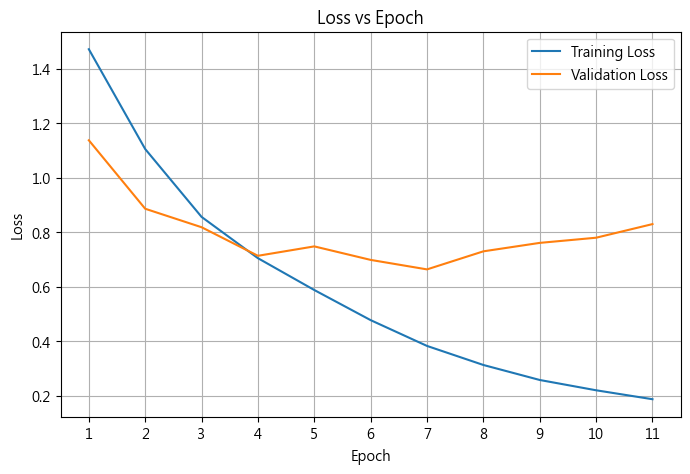

In [89]:
import matplotlib.pyplot as plt

epochs = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, history.history['loss'], label='Training Loss')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)  # 每個 epoch 顯示一個刻度
plt.legend()
plt.grid(True)
plt.show()

In [86]:
from scipy.sparse import issparse # 檢查是否為稀疏矩陣
from sklearn.metrics import accuracy_score #準確率
from sklearn.metrics import classification_report #分類報告
from sklearn.metrics import confusion_matrix #混淆矩陣
from tensorflow import keras
import numpy as np

loaded_model = keras.models.load_model("model_files/lstm_news_model_RMSprop.h5")
print('7-模型進行預估')
# predict1 = loaded_model.predict(X_test)
# predict2 = loaded_model.predict(X_train)

# 對測試集進行預測並取得類別標籤
if issparse(X_test):
    X_test_dense = X_test.toarray()
    predict_probabilities_test = loaded_model.predict(X_test_dense)
else:
    predict_probabilities_test = loaded_model.predict(X_test)
predict1 = np.argmax(predict_probabilities_test, axis=-1) # 取得機率最高的類別標籤

# 對訓練集進行預測並取得類別標籤
if issparse(X_train):
    predict_probabilities_train = loaded_model.predict(X_train.toarray())
else:
    predict_probabilities_train = loaded_model.predict(X_train)
predict2 = np.argmax(predict_probabilities_train, axis=-1) # 取得機率最高的類別標籤

print('8-模型進行評估')
print('訓練的準確率\n', accuracy_score(y_train, predict2))
print('測試的準確率\n', accuracy_score(y_test, predict1))
print('分類報告\n', classification_report(y_test, predict1))
print('混淆矩陣\n', confusion_matrix(y_test, predict1))

7-模型進行預估
266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
8-模型進行評估
訓練的準確率
 0.941755910284906
測試的準確率
 0.8202710665880967
分類報告
               precision    recall  f1-score   support

           0       0.86      0.81      0.83      1254
           1       0.84      0.87      0.86      2100
           2       0.80      0.79      0.79      2100
           3       0.69      0.75      0.72       931
           4       0.86      0.84      0.85      2100

    accuracy                           0.82      8485
   macro avg       0.81      0.81      0.81      8485
weighted avg       0.82      0.82      0.82      8485

混淆矩陣
 [[1014   53   38   50   99]
 [  41 1833   93   85   48]
 [  29  145 1653  156  117]
 [  13   79  119  700   20]
 [  88   63  161   28 1760]]


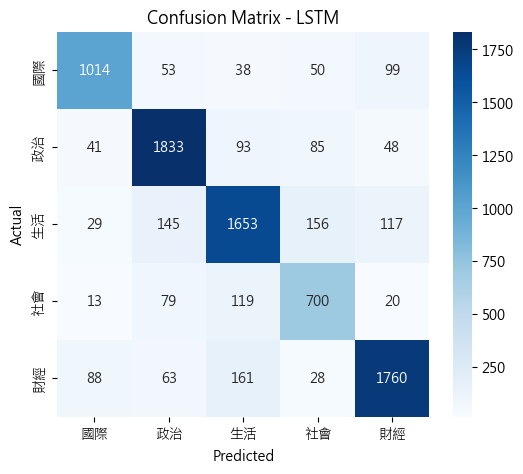

In [91]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.metrics import confusion_matrix
# 設定全域中文字型（Windows 常用字型：Microsoft JhengHei 微軟正黑體）
matplotlib.rcParams['font.family'] = 'Microsoft JhengHei'

# 假設 predict1 是你的模型預測結果
cm = confusion_matrix(y_test, predict1)
# 2️⃣ 取得 class 名稱對應
class_names = label_encoder.classes_

# 畫圖
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)  # fmt='d' 表示整數
plt.title('Confusion Matrix - LSTM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [27]:
# 預測單條句子
import jieba
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model
import pickle
import numpy as np

text = ["馬斯克發布政府效率部柴犬標誌 中國網友熱議"]  # 測試句子
# 1️⃣ 載入 Tokenizer
with open("model_files/tokenizer_lstm.pickle", "rb") as f:
    tokenizer = pickle.load(f)

# 2️⃣ 斷詞
cut_text = [" ".join(jieba.cut(t)) for t in text]

# 3️⃣ 轉成序列
seq = tokenizer.texts_to_sequences(cut_text)
X_single = pad_sequences(seq, maxlen=MAX_LEN, padding="post")

# 4️⃣ 載入模型
loaded_model = load_model("model_files/lstm_news_model.h5")

# 5️⃣ 預測
predict_probabilities = loaded_model.predict(X_single)
pred_label = np.argmax(predict_probabilities, axis=-1)

# 6️⃣ 載入 LabelEncoder 還原
with open("model_files/label_encoder_lstm.pickle", "rb") as f:
    label_encoder = pickle.load(f)
pred_class = label_encoder.inverse_transform(pred_label)

print("文字:", text[0])
print("預測類別:", pred_class[0])
print("各類別機率:", [f"{p:.6f}" for p in predict_probabilities[0]])


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 604ms/step
文字: 馬斯克發布政府效率部柴犬標誌 中國網友熱議
預測類別: 國際
各類別機率: ['0.610080', '0.224620', '0.032043', '0.013373', '0.119884']


In [14]:
import pandas as pd

# 載入當時使用的平衡資料集
df_balanced = pd.read_csv("run_results/ltn1_sentiment1_balanced.csv")

# 注意：train_test_split 時有 stratify，會打亂順序，所以需要重新切分 title
from sklearn.model_selection import train_test_split

titles = df_balanced["title"].values  # 原始標題
_, titles_test = train_test_split(
    titles,
    test_size=0.3,
    random_state=42,
    stratify=df_balanced["class_processed"].values
)

# 建立結果 DataFrame
results_df = pd.DataFrame({
    "title": titles_test,   # 對應的標題
    "y_true": y_test,       # 真實標籤
    "y_pred": predict1      # 預測標籤
})

# 預測機率 DataFrame
probs_df = pd.DataFrame(
    predict_probabilities_test,
    columns=[f"class_{i}" for i in range(predict_probabilities_test.shape[1])]
)

# 合併所有資訊
results_with_probs = pd.concat([results_df, probs_df], axis=1)

# 輸出 CSV
results_with_probs.to_csv("prediction_results_with_probs.csv", index=False, encoding="utf-8-sig")

print("✅ 已存成 prediction_results_with_probs.csv (包含 title、真實標籤、預測標籤、機率)")


✅ 已存成 prediction_results_with_probs.csv (包含 title、真實標籤、預測標籤、機率)


In [16]:
import pandas as pd

# 讀取結果檔
df_results = pd.read_csv("prediction_results_with_probs.csv")

# 篩選 y_true 與 y_pred 不相等的行
mismatches = df_results[df_results["y_true"] != df_results["y_pred"]]

# 顯示前幾筆，確認表格格式
from IPython.display import display
print("模型分類錯誤的資料筆數:", len(mismatches))
display(mismatches.head(20))  # 只先顯示前 20 筆，比較清爽

# 如果要存成新的 CSV
# mismatches.to_csv("prediction_mismatches.csv", index=False, encoding="utf-8-sig")
# print("✅ 已將錯誤預測的資料存成 prediction_mismatches.csv")


模型分類錯誤的資料筆數: 8


,title,y_true,y_pred,class_0,class_1,class_2
84,中小企業是「台灣寶貝」 副總統：被打壓後還有力量跳起來,2,1,0.001311,0.994447,0.004242
614,台灣設計展赫見名人鞋、「淤泥皮衣」 來看現省200元,1,2,0.000042,0.000134,0.999825
804,「中鋼-富田聯合實驗室」成立 深化電動車、無人機與AI機器人研究,2,0,0.956919,0.042582,0.000499
1641,邀各國使節齊賞九天技藝團鼓劇 林佳龍：體現「越在地越國際」,0,1,0.003818,0.993727,0.002455
1826,邀各國使節齊賞九天技藝團鼓劇 林佳龍：體現「越在地越國際」,0,1,0.003818,0.993727,0.002455
2136,台灣大: 每年斥資6.9億元投入AI研發,2,1,0.000510,0.987775,0.011715
2217,賴清德：盼與歐盟洽簽EPA 確保民主供應鏈,2,1,0.000338,0.857432,0.142230
2330,歐、日3大曝光機廠均下修業績 ! 台積電一家恐難挽狂瀾,2,1,0.000198,0.997063,0.002739
